In [1]:
import pandas as pd
import numpy as np

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [4]:
nav['date'] = pd.to_datetime(nav['date'])

nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [5]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [6]:
nav[['amfi_code','date','nav','daily_return']].head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [7]:
var_cvar = []

for fund in nav['amfi_code'].unique():

    returns = nav[nav['amfi_code'] == fund]['daily_return'].dropna()

    if len(returns) > 0:

        var_95 = np.percentile(returns, 5)

        cvar_95 = returns[returns <= var_95].mean()

        var_cvar.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report Saved Successfully")

Report Saved Successfully


In [9]:
top_funds = nav['amfi_code'].unique()[:5]

top_funds

array([100016, 100025, 100033, 101206, 101207])

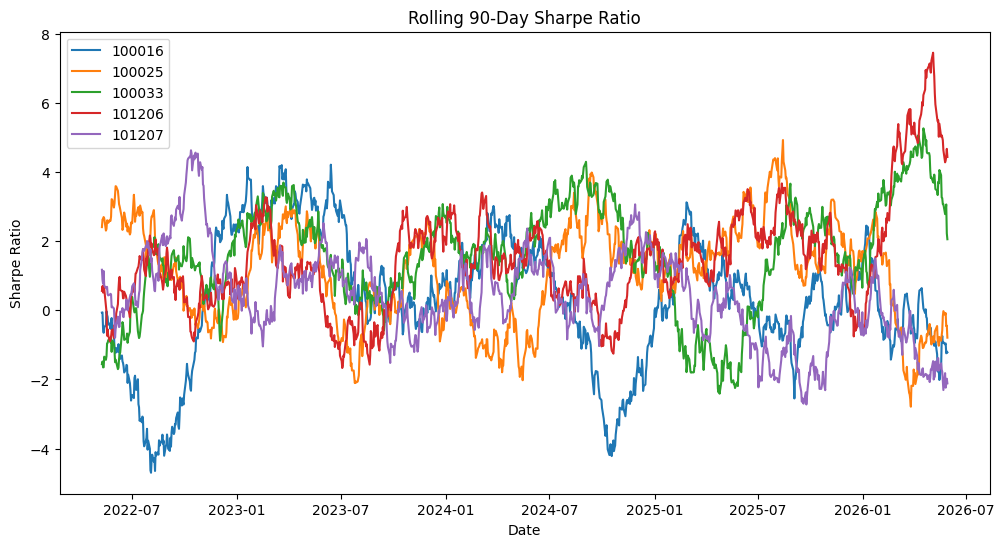

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top_funds:

    fund_data = nav[nav['amfi_code'] == fund].copy()

    fund_data['rolling_sharpe'] = (
        fund_data['daily_return'].rolling(90).mean()
        /
        fund_data['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data['date'],
        fund_data['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()

plt.title("Rolling 90-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.show()

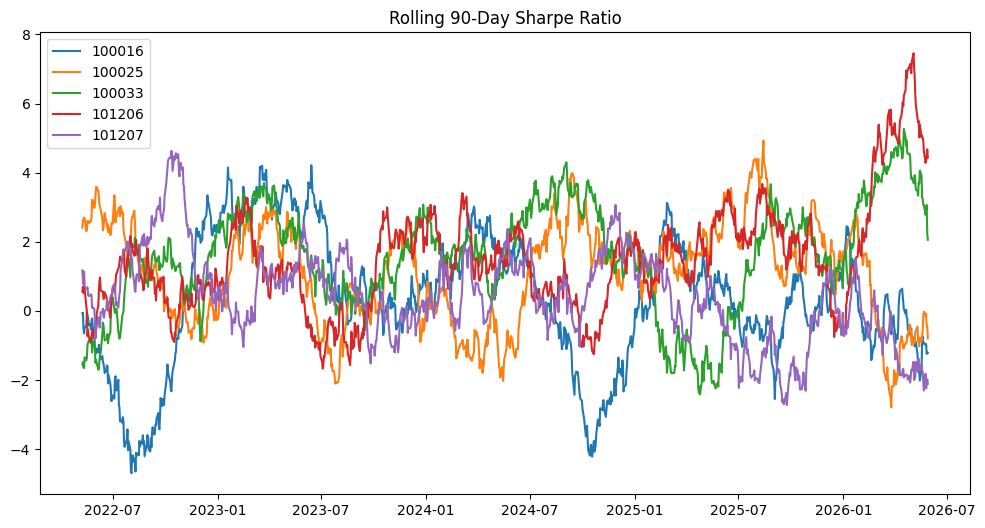

In [11]:
plt.figure(figsize=(12,6))

for fund in top_funds:

    fund_data = nav[nav['amfi_code'] == fund].copy()

    fund_data['rolling_sharpe'] = (
        fund_data['daily_return'].rolling(90).mean()
        /
        fund_data['daily_return'].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(
        fund_data['date'],
        fund_data['rolling_sharpe'],
        label=str(fund)
    )

plt.legend()

plt.title("Rolling 90-Day Sharpe Ratio")

plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

plt.show()

In [12]:
txn = pd.read_csv("../data/raw/08_investor_transactions.csv")

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [14]:
txn['transaction_date'] = pd.to_datetime(txn['transaction_date'])

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [15]:
first_txn = txn.groupby('investor_id')['transaction_date'].min().reset_index()

first_txn.columns = ['investor_id', 'first_transaction_date']

first_txn['cohort_year'] = first_txn['first_transaction_date'].dt.year

first_txn.head()

,investor_id,first_transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [16]:
txn = txn.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [17]:
cohort_analysis = txn.groupby('cohort_year').agg(
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum'),
    investor_count=('investor_id', 'nunique')
).reset_index()

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investor_count
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [18]:
cohort_analysis.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Cohort Analysis Saved")

Cohort Analysis Saved


In [19]:
txn = txn.sort_values(
    ['investor_id', 'transaction_date']
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [20]:
txn['gap_days'] = txn.groupby(
    'investor_id'
)['transaction_date'].diff().dt.days

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0


In [21]:
sip_continuity = txn.groupby(
    'investor_id'
).agg(
    transaction_count=('transaction_date', 'count'),
    avg_gap_days=('gap_days', 'mean')
).reset_index()

sip_continuity.head()

,investor_id,transaction_count,avg_gap_days
0,INV000001,3,38.000
1,INV000002,6,82.800
2,INV000003,2,238.000
3,INV000004,9,53.375
4,INV000005,8,52.000


In [22]:
sip_continuity = sip_continuity[
    sip_continuity['transaction_count'] >= 6
]

sip_continuity.head()

,investor_id,transaction_count,avg_gap_days
1,INV000002,6,82.800000
3,INV000004,9,53.375000
4,INV000005,8,52.000000
5,INV000006,6,99.000000
7,INV000008,8,50.285714


In [23]:
sip_continuity['risk_status'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

sip_continuity.head()

,investor_id,transaction_count,avg_gap_days,risk_status
1,INV000002,6,82.800000,At Risk
3,INV000004,9,53.375000,At Risk
4,INV000005,8,52.000000,At Risk
5,INV000006,6,99.000000,At Risk
7,INV000008,8,50.285714,At Risk


In [24]:
sip_continuity.to_csv(
    "../reports/sip_continuity.csv",
    index=False
)

print("SIP Continuity Report Saved")

SIP Continuity Report Saved


In [25]:
perf = pd.read_csv("../data/raw/07_scheme_performance.csv")

perf.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [26]:
perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [27]:
high_risk = perf[
    perf['risk_grade'] == 'High'
]

high_risk.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High
8,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High


In [28]:
top_high = high_risk.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(3)

top_high

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High


In [29]:
moderate_risk = perf[
    perf['risk_grade'] == 'Moderate'
]

top_moderate = moderate_risk.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(3)

top_moderate

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate


In [30]:
low_risk = perf[
    perf['risk_grade'] == 'Low'
]

top_low = low_risk.sort_values(
    by='sharpe_ratio',
    ascending=False
).head(3)

top_low

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,ABSL Liquid Fund - Regular - Growth,Aditya Birla Sun Life MF,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low


In [31]:
def recommend_funds(risk_level):

    if risk_level == "Low":
        return top_low

    elif risk_level == "Moderate":
        return top_moderate

    elif risk_level == "High":
        return top_high

    else:
        return "Invalid Risk Level"

In [32]:
recommend_funds("High")

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High


In [33]:
recommend_funds("moderate")

'Invalid Risk Level'

In [34]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [35]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [36]:
holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [37]:
hhi = holdings.groupby(
    ['amfi_code', 'sector']
)['weight_pct'].sum().reset_index()

hhi.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [38]:
hhi['weight_sq'] = hhi['weight_pct'] ** 2

hhi.head()

,amfi_code,sector,weight_pct,weight_sq
0,100016,Automobile,14.84,220.2256
1,100016,Banking,3.39,11.4921
2,100016,Energy,6.09,37.0881
3,100016,FMCG,11.68,136.4224
4,100016,IT,25.90,670.8100


In [39]:
hhi_report = hhi.groupby(
    'amfi_code'
)['weight_sq'].sum().reset_index()

hhi_report.rename(
    columns={'weight_sq': 'HHI'},
    inplace=True
)

hhi_report.head()

,amfi_code,HHI
0,100016,1805.8808
1,100033,2276.4744
2,101206,1800.4225
3,101207,2227.2651
4,102885,1807.1202


In [40]:
import numpy as np

hhi_report['concentration'] = np.where(
    hhi_report['HHI'] > 1500,
    'High Concentration',
    'Diversified'
)

hhi_report.head()

,amfi_code,HHI,concentration
0,100016,1805.8808,High Concentration
1,100033,2276.4744,High Concentration
2,101206,1800.4225,High Concentration
3,101207,2227.2651,High Concentration
4,102885,1807.1202,High Concentration


In [41]:
hhi_report.sort_values(
    by='HHI',
    ascending=False
).head(10)

,amfi_code,HHI,concentration
11,119092,2967.6909,High Concentration
30,148569,2549.9194,High Concentration
27,125498,2531.5500,High Concentration
6,102887,2513.8255,High Concentration
32,149323,2410.7664,High Concentration
21,120505,2386.9504,High Concentration
10,118635,2374.9677,High Concentration
18,119599,2323.6120,High Concentration
22,120506,2314.6434,High Concentration
1,100033,2276.4744,High Concentration


In [42]:
hhi_report.to_csv(
    "../reports/hhi_report.csv",
    index=False
)

print("HHI Report Saved")

HHI Report Saved


# Advanced Analytics Insights

1. Funds with the highest HHI show strong sector concentration and higher portfolio risk.

2. Several investors have average SIP gaps greater than 35 days and are classified as At Risk.

3. High-risk funds delivered the highest Sharpe Ratios among recommended schemes.

4. Investor cohorts entering in recent years contributed the highest average SIP investments.

5. Rolling Sharpe analysis shows significant variation in risk-adjusted performance across funds.

